# Intro (chargement des libraries et import des données)

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
    classification_report,
    ConfusionMatrixDisplay
)



# 1. Chargement des données
df = pd.read_csv('billets.csv', sep=';')

# Analyse et nettoyage des données

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [88]:
# Vérification et suppression des doublons
print(f"Doublons détectés : {df.duplicated().sum()}")

Doublons détectés : 0


In [89]:
df.isna().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Il va falloir trouver une solution pour remplacer les valeurs manquantes de margin_low ou les supprimer. <br> Une regression linéaire avec comme paramètre les autres colonnes? <br>
Vérifions la répartition des données avant.

In [90]:
df.loc[df['margin_low'].isna(), 'is_genuine'].value_counts()

is_genuine
True     29
False     8
Name: count, dtype: int64

37/1500 = 2.5% de valeur en moins, c'est acceptable puisque mon volume de données pour l'entrainement reste élevé (1463 lignes).<br>

D'autres part, mes Nan concernent 29 True et 8 False. La répartition est correct sachant que les False sont ma valeur rare pour entrainer mes modèles. <br>
On passe de 1000 T / 500 F (66.7% / 33.3%) à 971 T / 492 F (66.4% / 33.6%)<br><br>
De plus, je n'ai aucune variable dans mon dataset (hormis is_genuine) qui ne soit très fortement corrélée à margin_low.<br>
Imputer de nouvelles valeurs pour cette variable sachant cela est risqué pour nos résultats.<br>

Tous ces arguments me font penser que les supprimer est la meilleure option ( en plus  d'être la plus simple).

In [91]:
df = df.dropna().reset_index(drop=True)

In [92]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1463.0000,1463.0000,1463.0000,1463.0000,1463.0000,1463.0000
mean,171.9592,104.0313,103.9215,4.4860,3.1531,112.6748
std,0.3055,0.2996,0.3242,0.6638,0.2315,0.8732
min,171.0400,103.1400,102.9100,2.9800,2.2700,109.4900
25%,171.7500,103.8250,103.7100,4.0150,2.9900,112.0200
50%,171.9600,104.0400,103.9200,4.3100,3.1400,112.9600
75%,172.1700,104.2300,104.1500,4.8700,3.3150,113.3400
max,173.0100,104.8800,104.9500,6.9000,3.9100,114.3200


Il faut vérifier le zscore et l'iqr sur nos données.

In [93]:
# Liste de toutes les colonnes géométriques
colonnes_dimensions = [
    'diagonal',
    'height_left',
    'height_right',
    'margin_low',
    'margin_up',
    'length',
]

df_outliers_iqr = pd.DataFrame()
df_outliers_zscore = pd.DataFrame()

for col in colonnes_dimensions:
    # --- MÉTHODE 1 : IQR ---
    q25, q75 = np.nanquantile(df[col], [0.25, 0.75])
    iqr = q75 - q25

    limite_basse = q25 - 1.5 * iqr
    limite_haute = q75 + 1.5 * iqr

    df_outliers_iqr_temp = df[(df[col] < limite_basse) | (df[col] > limite_haute)]
    df_outliers_iqr_temp['outliers_col'] = col  # Ajout d'une colonne pour indiquer la colonne d'origine des outliers
    df_outliers_iqr = pd.concat([df_outliers_iqr, df_outliers_iqr_temp])

    
    # --- MÉTHODE 2 : Z-SCORE ---
    # On calcule le z-score à la volée en ignorant les NaN pour cette colonne
    z_scores = stats.zscore(df[col], nan_policy='omit')

    # On compte les lignes où le z-score dépasse 2 (en valeur absolue)
    df_outliers_zscore_temp = df[(z_scores < -2) | (z_scores > 2)]
    df_outliers_zscore_temp['outliers_col'] = col  # Ajout d'une colonne pour indiquer la colonne d'origine des outliers
    df_outliers_zscore = pd.concat([df_outliers_zscore, df_outliers_zscore_temp])
    
df_outliers_iqr = (
    df_outliers_iqr
    .value_counts(['outliers_col', 'is_genuine'])
    .reset_index(name='count')
)

df_outliers_zscore = (
    df_outliers_zscore
    .value_counts(['outliers_col', 'is_genuine'])
    .reset_index(name='count')
)

In [94]:
df_outliers_zscore

,outliers_col,is_genuine,count
0,margin_low,False,72
1,height_left,True,56
2,length,False,53
3,height_right,True,38
4,margin_up,False,37
5,diagonal,True,32
6,height_right,False,28
7,diagonal,False,23
8,margin_up,True,23
9,height_left,False,10


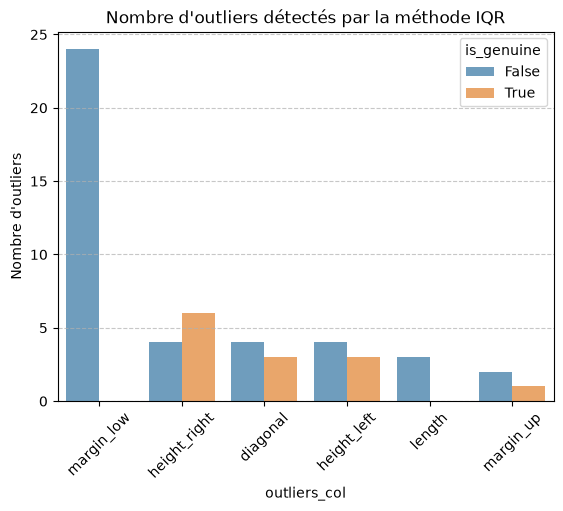

In [95]:
sns.barplot(x=df_outliers_iqr['outliers_col'], 
            y=df_outliers_iqr['count'], 
            hue=df_outliers_iqr['is_genuine'], 
            alpha=0.7)
plt.title("Nombre d'outliers détectés par la méthode IQR")
plt.ylabel("Nombre d'outliers")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()  

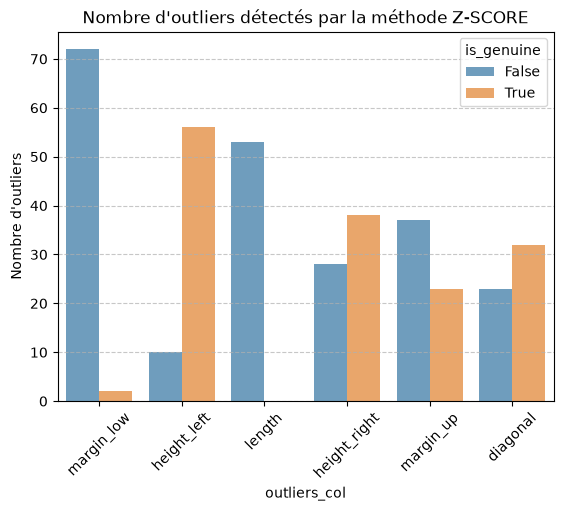

In [96]:
sns.barplot(x=df_outliers_zscore['outliers_col'], 
            y=df_outliers_zscore['count'], 
            hue=df_outliers_zscore['is_genuine'], 
            alpha=0.7)
plt.title("Nombre d'outliers détectés par la méthode Z-SCORE")
plt.ylabel("Nombre d'outliers")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()  

Il y a beaucoup d'outliers mais aucune raison de les supprimer. Au contraire, cela pourrait nous permettre d'identifier les faux billets !

Observons grâce aux boxplots ces outliers.

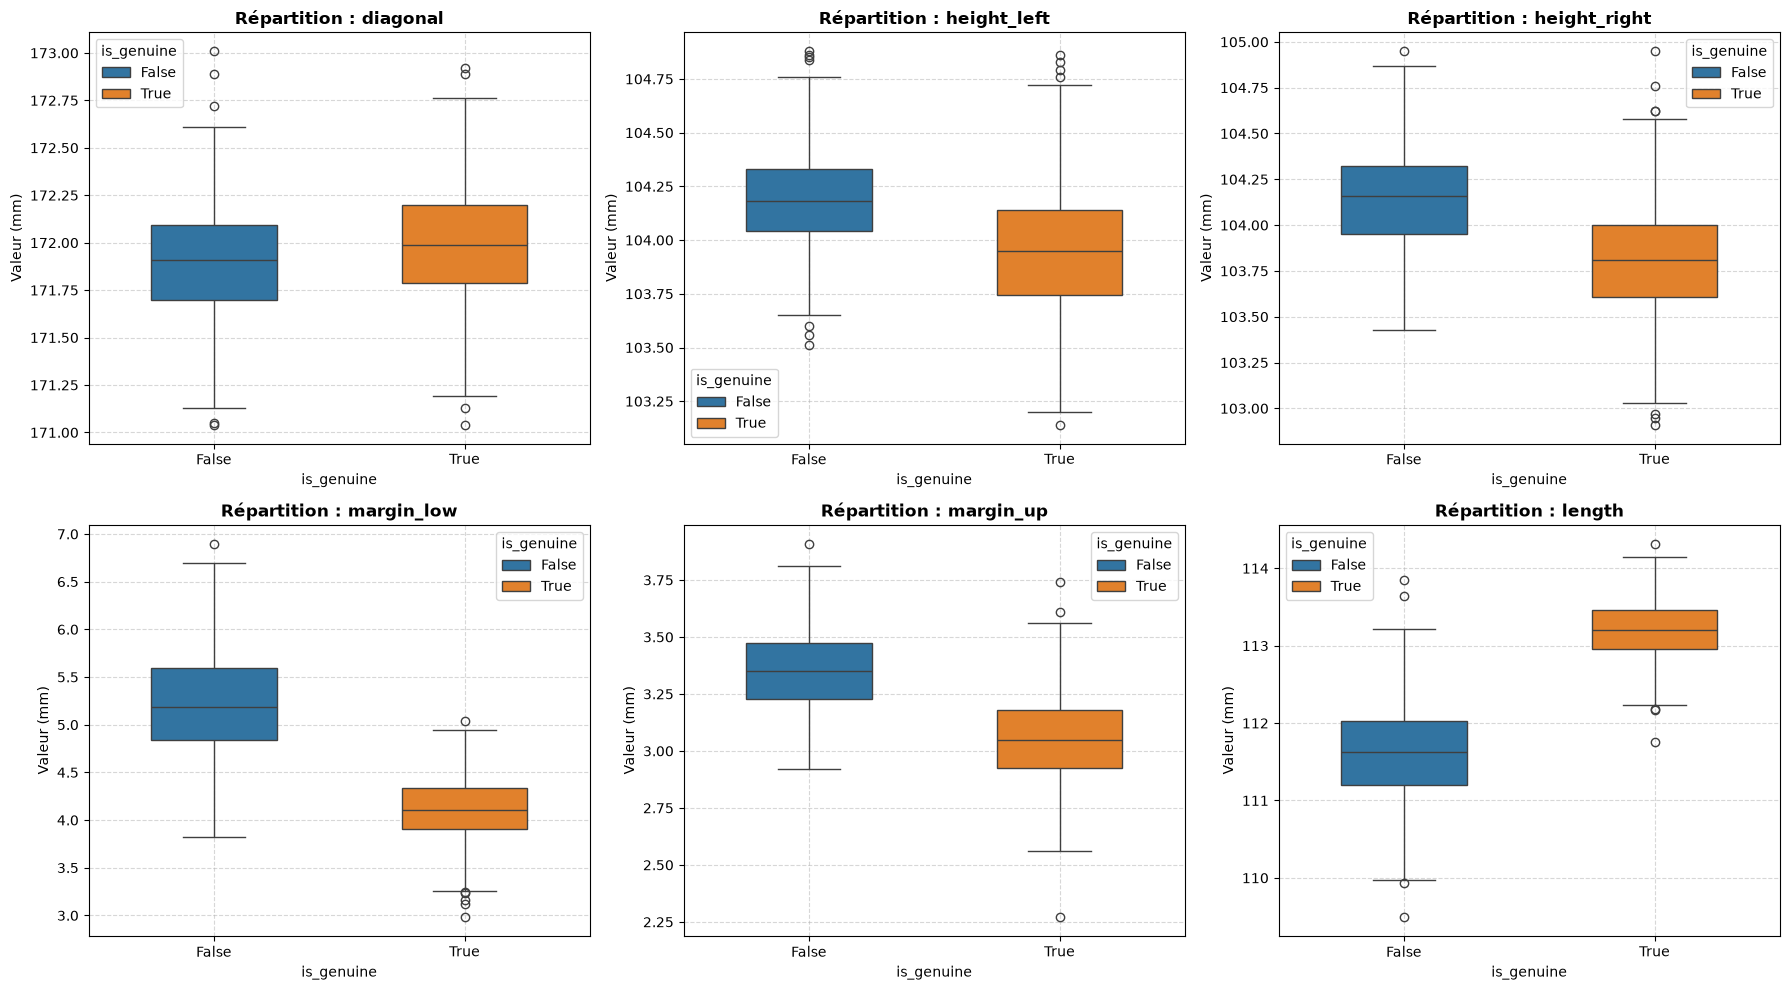

In [97]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# On "aplatit" la grille d'axes pour pouvoir boucler dessus facilement (passer de 2D à 1D)
axes = axes.flatten()

# 3. Boucle pour tracer le boxplot de chaque colonne
for i, col in enumerate(colonnes_dimensions):
    sns.boxplot(
    data=df, x='is_genuine', y=col, ax=axes[i], width=0.5, hue='is_genuine'
)
    # Personnalisation de chaque sous-graphique
    axes[i].set_title(f'Répartition : {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Valeur (mm)', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

# 4. Ajustement automatique des espaces pour éviter les chevauchements
plt.tight_layout()
plt.show()

Les données sont très ressérrées, cela explique les outliers mais ils ne sont pas spécifiques aux vrais ou faux billets.

Quoiqu'il en soit, aucune variable ne permet à elle seule de dire si un billet est vrai ou faux, les boites se recoupent trop sur chaque graphique.

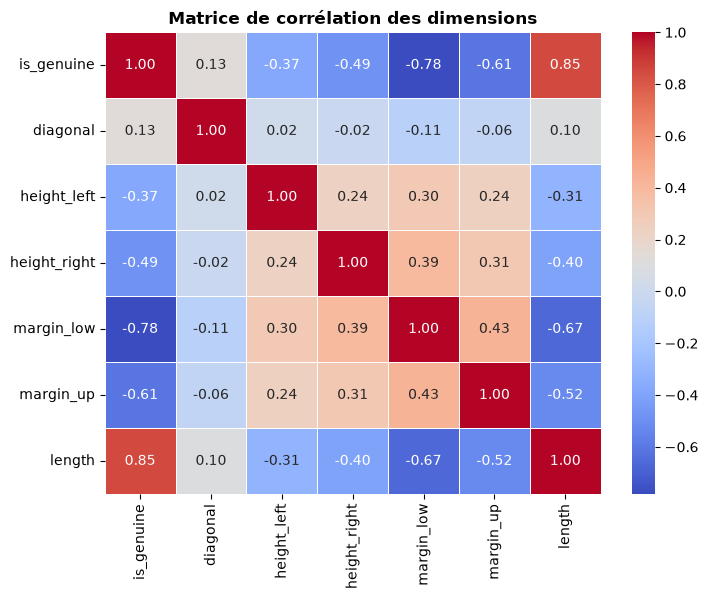

In [98]:
# Affichage des corrélations pour voir quelles dimensions sont liées
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des dimensions", fontsize=12, fontweight='bold')
plt.show()

Certaines variables semblent quand même très corrélées(lenght/margin_low/margin_up)

C'est pourquoi nous allons utiliser le machine learning pour détecter les billets.

# Regression logistique

## Régression logistique classique 

C'est parti pour le premier algorithme.

In [99]:
#On défini nos variables prédictrices (X) et notre variable cible (y)

X = df[['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]

y = df['is_genuine']

In [100]:
# On sépare le jeu de données en 2 : 
# Une pour l'entrainement, une pour le test qui sert à valider l'entrainement.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=808)

# On instancie le modèle, ici avec un pipeline pour centrer réduire nos données.
# on scale aussi nos données
# # En effet, la régression logistique est sensible à l'échelle. 
# Centrer/réduire va ramener nos données avec une moyenne =0 et std = 1.
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=808))

In [101]:
# On entraine le modèle
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['diagonal','height_left','height_right','margin_low','margin_up','length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Faisons lui deviner un billet désormais !

In [102]:
# Choisissons un billet entre 0 et 1463, au hasard 42
un_billet = X.iloc[[42]]

#Imprimons le résultat du modèle
print(clf.predict(un_billet))

# Voyons le resultat réel:
print(y.iloc[[42]])

[ True]
42    True
Name: is_genuine, dtype: bool


C'est bien le même resultat, bravo la regression logistique.

Regardons maintenant les scores de notre modèle

In [103]:
# On va d'abord générer les prédictions
y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)[:, 1]

       RÉSUMÉ DES PERFORMANCES
Accuracy  (Précision globale) : 0.9932
Precision (Fiabilité du Vrai) : 0.9895
Recall    (Taux de détection) : 1.0000
F1-Score  (Synthèse P/R)      : 0.9947
ROC-AUC   (Pouvoir séparateur): 0.9968


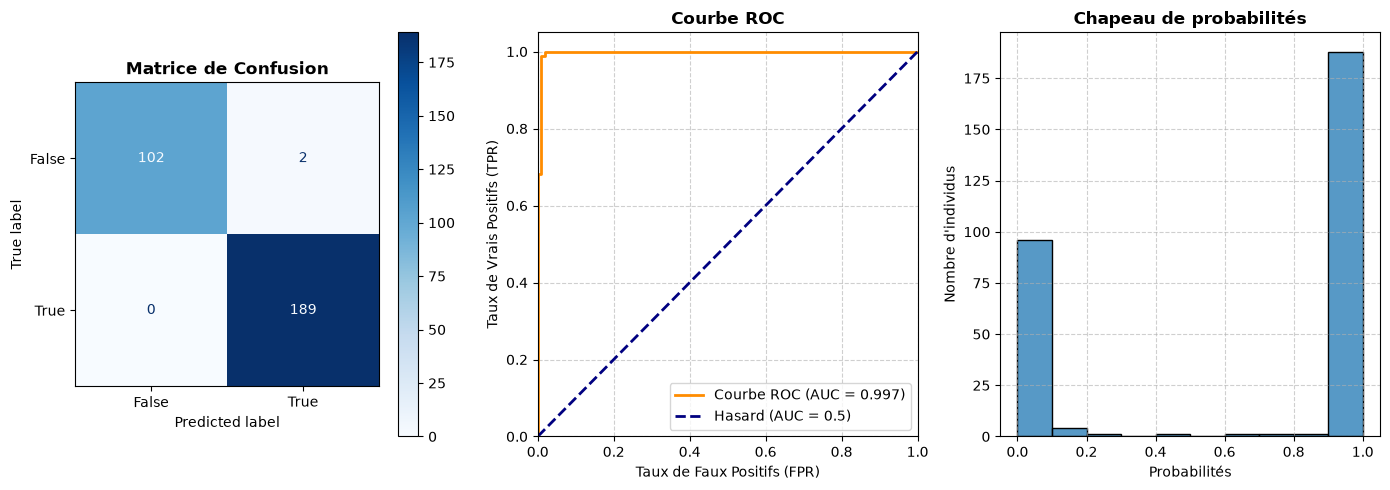

In [104]:
# On Calcule les métriques individuelles
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

# Affichage textuel propre
print("="*40)
print("       RÉSUMÉ DES PERFORMANCES")
print("="*40)
print(f"Accuracy  (Précision globale) : {accuracy:.4f}")
print(f"Precision (Fiabilité du Vrai) : {precision:.4f}")
print(f"Recall    (Taux de détection) : {recall:.4f}")
print(f"F1-Score  (Synthèse P/R)      : {f1:.4f}")
print(f"ROC-AUC   (Pouvoir séparateur): {roc_auc:.4f}")
print("="*40)

# Affichage des graphiques (Matrice de confusion, Courbe ROC et Chapeau de probabilités)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

# --- Graphique 1 : Matrice de Confusion ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title("Matrice de Confusion", fontsize=12, fontweight='bold')

# --- Graphique 2 : Courbe ROC ---
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.5)')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("Taux de Faux Positifs (FPR)")
ax2.set_ylabel("Taux de Vrais Positifs (TPR)")
ax2.set_title("Courbe ROC", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc="lower right")

# --- Graphique 3 : Chapeau de probabilités ---
sns.histplot(y_probs)
ax3.set_xlabel("Probabilités")
ax3.set_ylabel("Nombre d'individus")
ax3.set_title("Chapeau de probabilités", fontsize=12, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

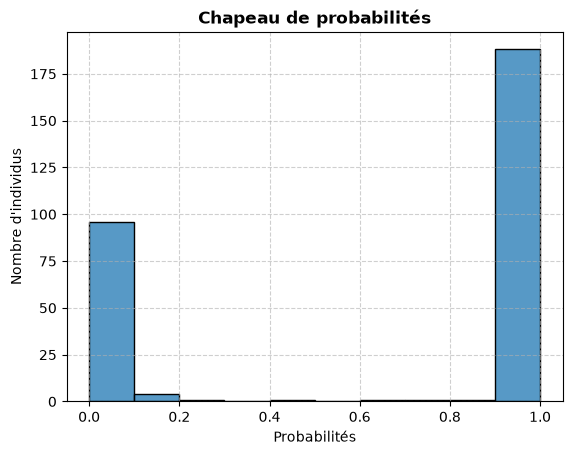

In [105]:
sns.histplot(y_probs)
plt.xlabel("Probabilités")
plt.ylabel("Nombre d'individus")
plt.title("Chapeau de probabilités", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

On a de très bons résultats (pour ce random state) : <br>
La matrice de confusion ne donne que 2 faux positifs(FP) ===> (faux billets détéctés en vrais)<br>
Accuracy : Qualité globale des prédictions très bonnes à 99.32%<br>
Precision : très bonne aussi mais impactée par les 2 FP 98.95%<br>
Recall : Les vrais détectés comme des faux = 0. 100%<br>
F1 : synthèse de recall et precision : 99.47%<br>
ROC AUC : Mesure la capacité du modèle à extrapoler efficacement : 99.68% C'est presque parfait.<br>

C'est résultats sont excellents mais voyons voir si on entraine 200x le modèle avec des "seed" différentes pour <br>
train_test_split et LogisticRegression

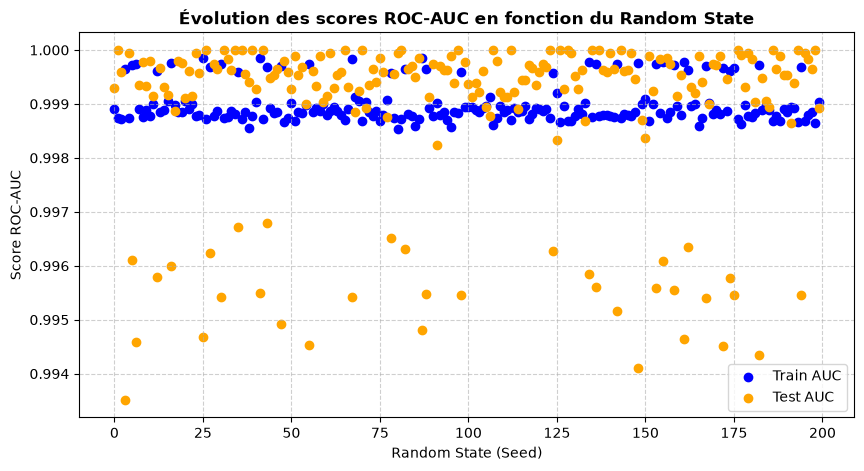

Score Test Moyen : 0.9988
Écart-type Test (Variance) : 0.0016


In [106]:
results = []

# On teste 200 valeurs de random_state différentes (de 0 à 199)
for seed in range(200):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

    # Le random_state change à chaque itération pour le découpage
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=seed))
    model.fit(X_train, y_train)

    
    # Calcul des scores ROC-AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results.append({
        'random_state': seed,
        'train_auc': train_auc,
        'test_auc': test_auc
    })

# Conversion en DataFrame
df_results_raw = pd.DataFrame(results)

# --- Visualisation des variations ---
plt.figure(figsize=(10, 5))
plt.scatter(df_results_raw['random_state'], df_results_raw['train_auc'], marker='o', label='Train AUC', color='blue')
plt.scatter(df_results_raw['random_state'], df_results_raw['test_auc'], marker='o', label='Test AUC', color='orange')
plt.title("Évolution des scores ROC-AUC en fonction du Random State", fontsize=12, fontweight='bold')
plt.xlabel("Random State (Seed)")
plt.ylabel("Score ROC-AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Affichage des statistiques pour juger de la stabilité
print(f"Score Test Moyen : {df_results_raw['test_auc'].mean():.4f}")
print(f"Écart-type Test (Variance) : {df_results_raw['test_auc'].std():.4f}")

Les scores sur train sont bons (très serrés autour de 99.9%), le modèle apprend de manière régulière quelque soit le mélange dans les données d'entrainement.

Le score sur les tests sont toujours très bons (entre 99.4 et 100%, moyenne = 99.88%) et peu variés, le modèle est donc robuste aux nouveaux jeux de données.

Conclusion : Le modèle est performant et permet de detecter efficacement les billets.

## Regression logistique avec features engineering

Essayons en introduisant de nouvelles variables pour notre regression.

In [107]:
df_fe = df.copy()

# Introduisons une variable sur la différence de hauteur gauche/droite
df_fe['height_diff'] = df_fe['height_left'] - df_fe['height_right']

# Une variable sur le ratio entre les marges
df_fe['margin_ratio'] = df_fe['margin_low'] / df_fe['margin_up']

# Une autre sur le ratio entre la longueur et la diagonale.
df_fe['length_diagonal_ratio'] = df_fe['length'] / df_fe['diagonal']

In [108]:
# On redéfini X
X_fe = df_fe[['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up',
            'length','height_diff', 'margin_ratio', 'length_diagonal_ratio']]

On va l'entrainer sur 200 seeds également et voir si on obtient de meilleurs resultats

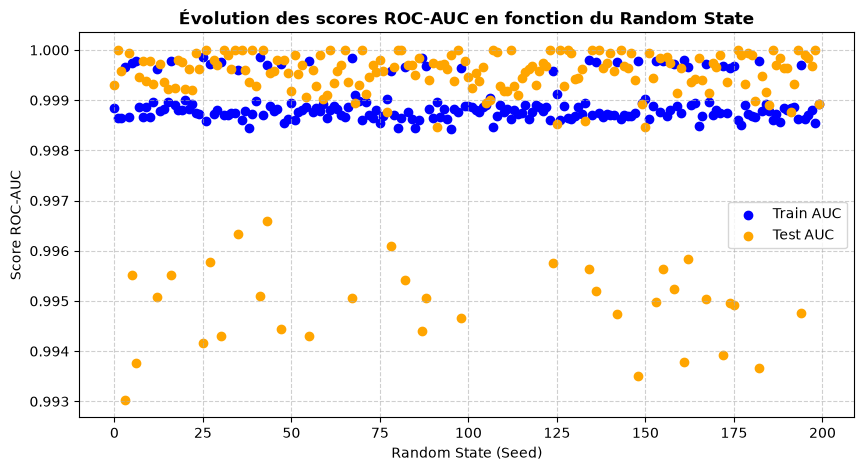

Score Test Moyen : 0.9988
Écart-type Test (Variance) : 0.0018


In [109]:
results = []

# On teste 200 valeurs de random_state différentes (de 0 à 199)
for seed in range(200):
    # Le random_state change à chaque itération pour le découpage
    X_train, X_test, y_train, y_test = train_test_split(X_fe, y, test_size=0.2, random_state=seed)
    
    # Entraînement de la Régression Logistique
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=seed))
    model.fit(X_train, y_train)
    
    # Calcul des scores ROC-AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results.append({
        'random_state': seed,
        'train_auc': train_auc,
        'test_auc': test_auc
    })

# Conversion en DataFrame
df_results_fe = pd.DataFrame(results)

# --- Visualisation des variations ---
plt.figure(figsize=(10, 5))
plt.scatter(df_results_fe['random_state'], df_results_fe['train_auc'], marker='o', label='Train AUC', color='blue')
plt.scatter(df_results_fe['random_state'], df_results_fe['test_auc'], marker='o', label='Test AUC', color='orange')
plt.title("Évolution des scores ROC-AUC en fonction du Random State", fontsize=12, fontweight='bold')
plt.xlabel("Random State (Seed)")
plt.ylabel("Score ROC-AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Affichage des statistiques pour juger de la stabilité
print(f"Score Test Moyen : {df_results_fe['test_auc'].mean():.4f}")
print(f"Écart-type Test (Variance) : {df_results_fe['test_auc'].std():.4f}")

Les resultats sont très similaires. Les nouvelles features n'ont rien apportées.

## Regression logistique avec avec variables polynominales

In [110]:
#on va utiliser un module qui génère automatiquement des combinaisons de variables
from sklearn.preprocessing import PolynomialFeatures

# On génère les interactions (de degré 2) uniquement sur nos variables
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
y = df['is_genuine']

même tarif ici pour tester le modèle.

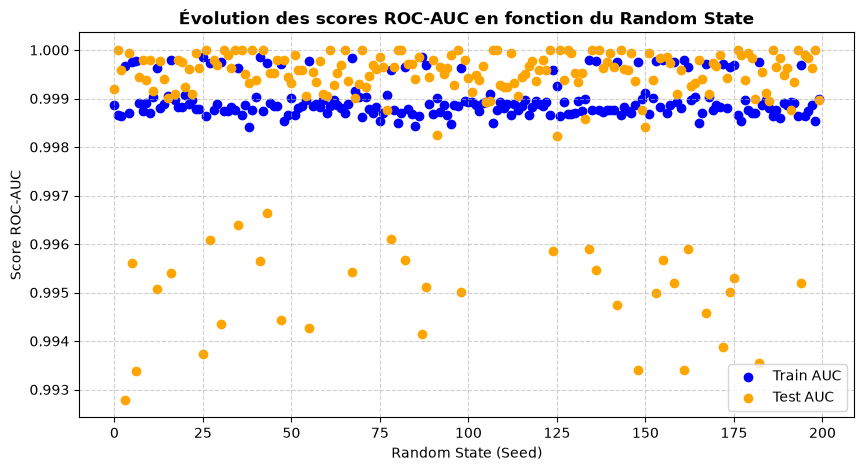

Score Test Moyen : 0.9988
Écart-type Test (Variance) : 0.0018


In [111]:
results = []

# On teste 200 valeurs de random_state différentes (de 0 à 199)
for seed in range(200):
    # Le random_state change à chaque itération pour le découpage
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=seed)
    
    # Entraînement de la Régression Logistique
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=seed))
    model.fit(X_train, y_train)

    
    # Calcul des scores ROC-AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results.append({
        'random_state': seed,
        'train_auc': train_auc,
        'test_auc': test_auc
    })

# Conversion en DataFrame
df_results_poly = pd.DataFrame(results)

# --- Visualisation des variations ---
plt.figure(figsize=(10, 5))
plt.scatter(df_results_poly['random_state'], df_results_poly['train_auc'], marker='o', label='Train AUC', color='blue')
plt.scatter(df_results_poly['random_state'], df_results_poly['test_auc'], marker='o', label='Test AUC', color='orange')
plt.title("Évolution des scores ROC-AUC en fonction du Random State", fontsize=12, fontweight='bold')
plt.xlabel("Random State (Seed)")
plt.ylabel("Score ROC-AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Affichage des statistiques pour juger de la stabilité
print(f"Score Test Moyen : {df_results_poly['test_auc'].mean():.4f}")
print(f"Écart-type Test (Variance) : {df_results_poly['test_auc'].std():.4f}")

Les resultats sont très similaires. Les nouvelles features n'ont rien apportées.

## Regression logistique avec moins de variables

In [112]:
X_reduit = df[['margin_low', 'margin_up', 'length']]

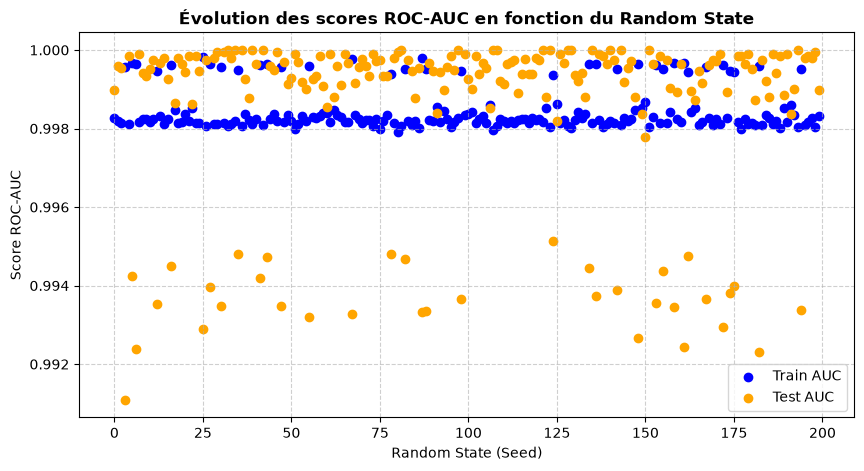

Score Test Moyen : 0.9985
Écart-type Test (Variance) : 0.0023


In [113]:
results = []

# On teste 200 valeurs de random_state différentes (de 0 à 199)
for seed in range(200):
    X_train, X_test, y_train, y_test = train_test_split(X_reduit, y, test_size=0.20, random_state=seed)

    # Le random_state change à chaque itération pour le découpage
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=seed))
    model.fit(X_train, y_train)

    
    # Calcul des scores ROC-AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results.append({
        'random_state': seed,
        'train_auc': train_auc,
        'test_auc': test_auc
    })

# Conversion en DataFrame
df_results_reduit = pd.DataFrame(results)

# --- Visualisation des variations ---
plt.figure(figsize=(10, 5))
plt.scatter(df_results_reduit['random_state'], df_results_reduit['train_auc'], marker='o', label='Train AUC', color='blue')
plt.scatter(df_results_reduit['random_state'], df_results_reduit['test_auc'], marker='o', label='Test AUC', color='orange')
plt.title("Évolution des scores ROC-AUC en fonction du Random State", fontsize=12, fontweight='bold')
plt.xlabel("Random State (Seed)")
plt.ylabel("Score ROC-AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Affichage des statistiques pour juger de la stabilité
print(f"Score Test Moyen : {df_results_reduit['test_auc'].mean():.4f}")
print(f"Écart-type Test (Variance) : {df_results_reduit['test_auc'].std():.4f}")

Résultat moins bon qu'avec toutes les variables.

## Conclusion Regression logistique

In [155]:
# Tableau comparatif des scores ROC-AUC moyens et de leur écart-type
summary_results = {
    "raw": df_results_raw,
    "fe": df_results_fe,
    "poly": df_results_poly,
    "reduit": df_results_reduit,
}

summary_df = pd.DataFrame(
    [
        {
            "dataset": name,
            "mean_test_auc": df["test_auc"].mean(),
            "std_test_auc": df["test_auc"].std(),
        }
        for name, df in summary_results.items()
    ]
).set_index("dataset")

pd.options.display.float_format = "{:.4f}".format
display(summary_df.sort_values("mean_test_auc", ascending=False))


,mean_test_auc,std_test_auc
dataset,,
raw,0.9988,0.0016
fe,0.9988,0.0018
poly,0.9988,0.0018
reduit,0.9985,0.0023


La regression logistique fonctionne presque aussi bien avec 3 variables que 6 mais la version de base reste la plus performante.

# Kmeans

Kmeans est un algorithme non supervisé, il n'a donc pas besoin 

On va d'abord tester notre kmeans pour voir combien de clusters donnent le meilleur silhouette score et la meilleure inertie

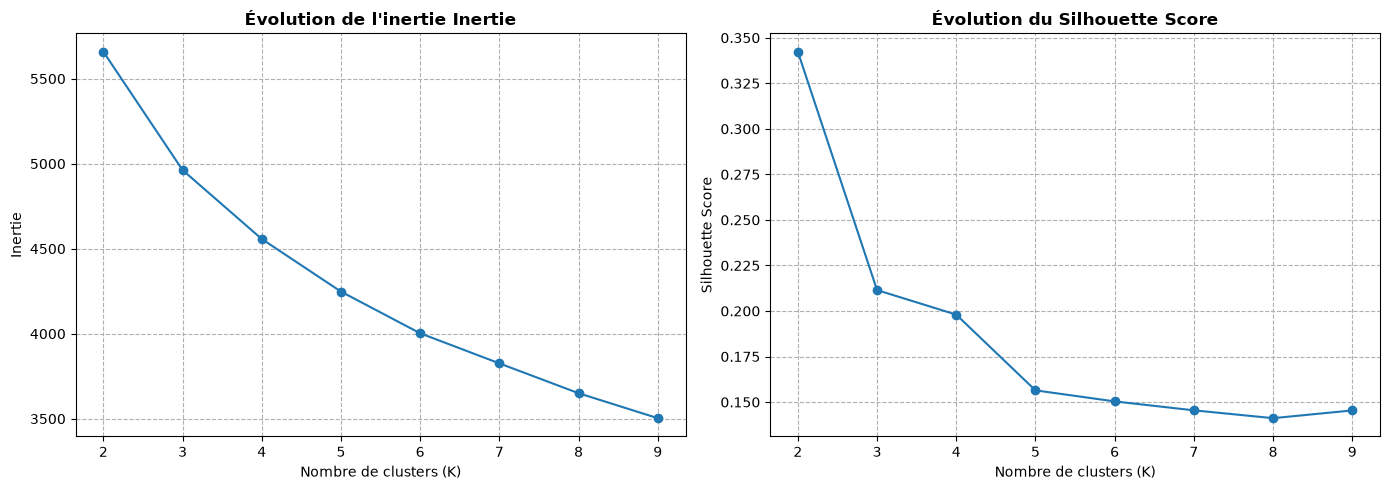

In [115]:
# On crée nos listes pour enregistrer nos scores
inerties = []
silhouette_scores = []
liste_k = range(2, 10) # Silhouette a besoin d'au moins 2 clusters pour exister

for k in liste_k: # On va boucler pour trouver le nombre de clusters idéal
    kmeans = make_pipeline(StandardScaler(),
                           KMeans(n_clusters=k, random_state=42, n_init=10)) #On instancie toujours avec scaler()
    kmeans.fit(X) 
    
    scaler_step = kmeans[0]
    kmeans_step = kmeans[-1] 
    X_scaled = scaler_step.transform(X)
    
    # 5. On récupère les scores directement sur l'étape kmeans_step
    inerties.append(kmeans_step.inertia_) 
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_step.labels_)) # on récupère le silhouette score

# --- Graphique 1 : L'Inertie ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(liste_k, inerties, marker='o')
ax1.set_title("Évolution de l'inertie Inertie", fontweight='bold')
ax1.set_xlabel("Nombre de clusters (K)")
ax1.set_ylabel("Inertie")
ax1.grid(True, linestyle='--')

# --- Graphique 2 : Le Silhouette Score ---
ax2.plot(liste_k, silhouette_scores, marker='o')
ax2.set_title("Évolution du Silhouette Score", fontweight='bold')
ax2.set_xlabel("Nombre de clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

L'inertie mesure la somme des distances au carré entre les points et le centre de leur groupe. Plus elle est faible, mieux c'est. <br>

Pour l'inertie, la pente est très régulière donc il n'y a pas d'interêt à avoir plus de 2 clusters.<br>
D'autant plus que nous voulons séparer les vrais billets des faux.

Le score de silhouette évalue la qualité géométrique des clusters sur une échelle de -1(mauvais) à +1(bon) <br>

Le graphique montre clairement qu'au delà de 2 clusters, le score baisse énormément.<br>

2 clusters semblent donc être le bon choix.

In [116]:
k_means = make_pipeline(StandardScaler(), KMeans(init="k-means++",
             n_clusters=2, random_state = 808 , n_init = 'auto')) # On instancie
k_means.fit(X) # on entraine

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['diagonal','height_left','height_right','margin_low','margin_up','length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [117]:
k_means_labels = k_means.predict(X)
X_scaled = k_means[0].transform(X)

print("="*40)
print("       RÉSUMÉ DES PERFORMANCES")
print("="*40)
print(f"Score (Inertie) : {k_means[-1].inertia_:.4f}")  # Rendre positif
print(f"Silhouette score (Train) : {silhouette_score(X_scaled, k_means_labels):.4f}")
print(f"Silhouette score (classes réelles) : {silhouette_score(X_scaled, y):.4f}")
print("="*40)

       RÉSUMÉ DES PERFORMANCES
Score (Inertie) : 5659.0067
Silhouette score (Train) : 0.3426
Silhouette score (classes réelles) : 0.3369


Le score n'a pas de valeur intrinsèque, il sert surtout à comparer les modèles entre eux. <br>
Les silhouette-scores de 0.342 et 0.337 montrent que l'algorithme ne parvient pas à bien séparer les points entre les deux clusters dans l'espace. Les données présentent un certain chevauchement.
En revanche, il trouve une séparation géométrique très cohérente avec la véritable donnée (scores proches).

Visualisons nos clusters dans un espace à 2 dimensions grâce à la PCA qui va réduire nos variables prédictrices à 2.

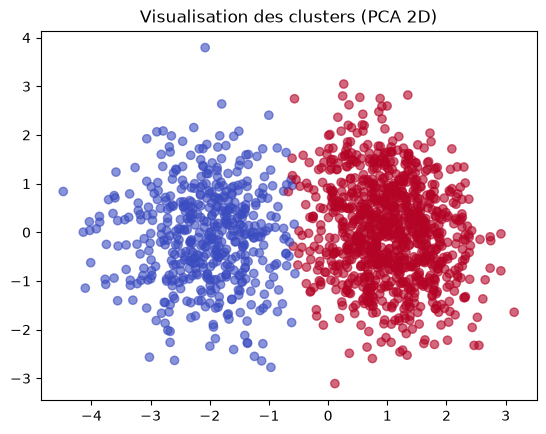

In [118]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=k_means_labels, cmap='coolwarm', alpha=0.6)
plt.title("Visualisation des clusters (PCA 2D)")
plt.show()

In [119]:
# Correspondance clusters / vraie classe ou table de corrélation.
pd.crosstab(k_means_labels, y)

is_genuine,False,True
row_0,,
0,478,9
1,14,962


In [120]:
y_pred = k_means_labels

acc = accuracy_score(y, y_pred)
print(f"Accuracy : {acc:.4f}")

# 3. Pour un résumé complet (Precision, Recall, F1-Score)
print("\nRapport complet :")
print(classification_report(y, y_pred))

Accuracy : 0.9843

Rapport complet :
              precision    recall  f1-score   support

       False       0.98      0.97      0.98       492
        True       0.99      0.99      0.99       971

    accuracy                           0.98      1463
   macro avg       0.98      0.98      0.98      1463
weighted avg       0.98      0.98      0.98      1463



Le cluster 1 correspond aux vrais billets. On retrouve beaucoup d'erreurs dans notre modèle (14 Faux positifs et 9 faux négatifs)

In [121]:
# Profil moyen de chaque cluster
df.groupby(k_means_labels)[colonnes_dimensions].mean()

,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.8999,104.1994,104.1513,5.2239,3.3533,111.6302
1,171.9888,103.9475,103.8068,4.1178,3.0532,113.1960


Les vrais billets se caractérisent par une marge basse plus faible en moyenne.

Conclusion : Le k-means est moins performant que la regression logistique pour notre projet.

## Test du K-means avec moins de dimensions

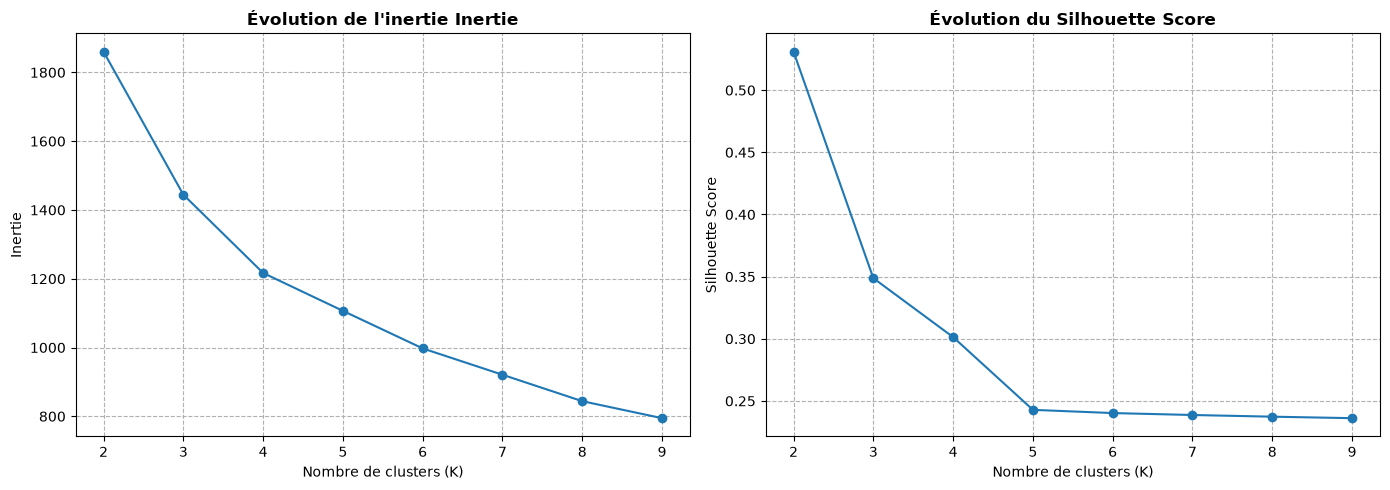

In [122]:
# On crée nos listes pour enregistrer nos scores
inerties = []
silhouette_scores = []
liste_k = range(2, 10) # Silhouette a besoin d'au moins 2 clusters pour exister

for k in liste_k: # On va boucler
    kmeans = make_pipeline(StandardScaler(),
                           KMeans(n_clusters=k, random_state=42, n_init=10)) #On instancie toujours avec scaler()
    kmeans.fit(X_reduit) 
    
    scaler_step = kmeans[0]
    kmeans_step = kmeans[-1] 
    X_scaled = scaler_step.transform(X_reduit)
    
    # On récupère les scores directement sur l'étape kmeans_step
    inerties.append(kmeans_step.inertia_) 
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_step.labels_)) # on récupère le silhouette score

# --- Graphique 1 : L'Inertie ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(liste_k, inerties, marker='o')
ax1.set_title("Évolution de l'inertie Inertie", fontweight='bold')
ax1.set_xlabel("Nombre de clusters (K)")
ax1.set_ylabel("Inertie")
ax1.grid(True, linestyle='--')

# --- Graphique 2 : Le Silhouette Score ---
ax2.plot(liste_k, silhouette_scores, marker='o')
ax2.set_title("Évolution du Silhouette Score", fontweight='bold')
ax2.set_xlabel("Nombre de clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

Les scores ont l'air bien meilleurs qu'avec l'ensemble des dimensions

In [123]:

k_means = make_pipeline(StandardScaler(), KMeans(init="k-means++",
             n_clusters=2, random_state = 808 , n_init = 'auto')) # On instancie
k_means.fit(X_reduit) # on entraine

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['margin_low','margin_up','length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [124]:
inerties = []
silhouette_scores = []

# On extrait les étapes du pipeline
scaler_step = k_means[0]
k_means_step = k_means[-1] 

# On scale X
X_scaled = scaler_step.transform(X_reduit)

# On récupère les scores directement sur l'étape k_means_step
inerties.append(k_means_step.inertia_) 
silhouette_scores.append(silhouette_score(X_scaled, k_means_step.labels_))

k_means_labels = k_means.predict(X_reduit)

# Affichage textuel propre
print("="*40)
print("       RÉSUMÉ DES PERFORMANCES")
print("="*40)
print(f"Score  (Inertie) : {k_means.score(X_reduit):.4f}")
print(f"Silhouette score (Train) : {silhouette_score(X_scaled,k_means_labels):.4f}")
print(f"Silhouette score (classes réelles) : {silhouette_score(X_scaled,y):.4f}")
print("="*40)

       RÉSUMÉ DES PERFORMANCES
Score  (Inertie) : -1860.2948
Silhouette score (Train) : 0.5310
Silhouette score (classes réelles) : 0.5225


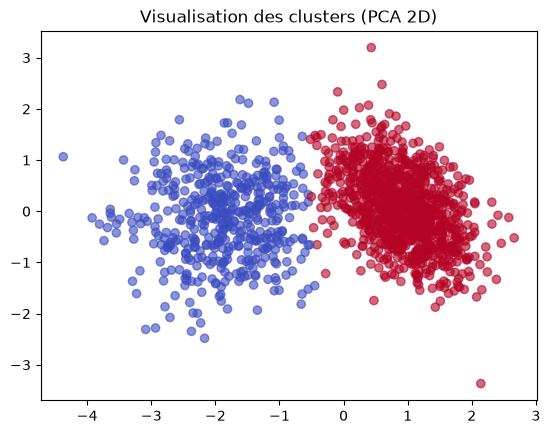

In [125]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=k_means_labels, cmap='coolwarm', alpha=0.6)
plt.title("Visualisation des clusters (PCA 2D)")
plt.show()

Les deux groupes ont l'air plus denses et mieux identifiés.

In [126]:
pd.crosstab(k_means_labels, y)

is_genuine,False,True
row_0,,
0,476,3
1,16,968


Il reste encore beaucoup d'erreurs : notamment 16 Faux positifs. K-means reste moins performant que les autres modèles.

# KNN

On va encore benchmark notre modèle pour avoir les meilleurs paramètres : ici le nombre de voisins

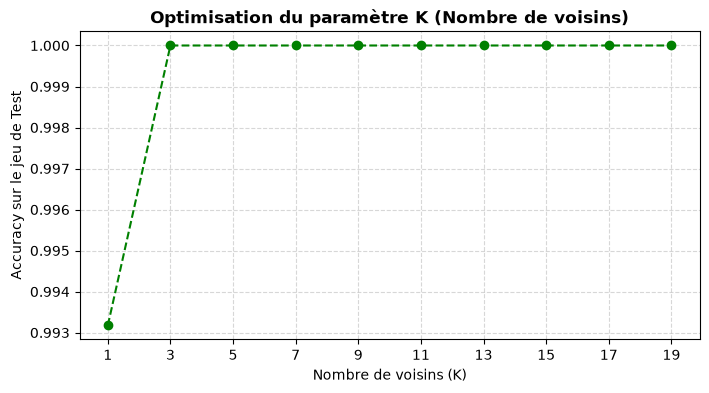

In [127]:
# on relance une instance de train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# On teste les K impairs de 1 à 19 pour éviter les égalités
liste_k = np.arange(1, 20, 2)
scores_test = []

for k in liste_k:
    # On recrée un pipeline avec le k actuel
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train, y_train)
    scores_test.append(model.score(X_test, y_test))

# --- Graphique de l'optimisation de K ---
plt.figure(figsize=(8, 4))
plt.plot(liste_k, scores_test, marker='o', color='green', linestyle='--')
plt.title("Optimisation du paramètre K (Nombre de voisins)", fontsize=12, fontweight='bold')
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Accuracy sur le jeu de Test")
plt.xticks(liste_k)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

On obtient une accuracy à 1 pour 3 voisins.

In [128]:
# On choisit donc n_neighbors=3 
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))

# On entraine
knn.fit(X_train, y_train)

# Prédictions
y_pred = knn.predict(X_test)
y_probs = knn.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

# Affichage textuel propre
print("="*40)
print("       RÉSUMÉ DES PERFORMANCES")
print("="*40)
print(f"Accuracy  (Précision globale) : {accuracy:.4f}")
print(f"Precision (Fiabilité du Vrai) : {precision:.4f}")
print(f"Recall    (Taux de détection) : {recall:.4f}")
print(f"F1-Score  (Synthèse P/R)      : {f1:.4f}")
print(f"ROC-AUC   (Pouvoir séparateur): {roc_auc:.4f}")
print("="*40)

       RÉSUMÉ DES PERFORMANCES
Accuracy  (Précision globale) : 1.0000
Precision (Fiabilité du Vrai) : 1.0000
Recall    (Taux de détection) : 1.0000
F1-Score  (Synthèse P/R)      : 1.0000
ROC-AUC   (Pouvoir séparateur): 1.0000


Pour cette seed le knn a très bien trié nos billets mais voyons son résultat sur 200 seeds.

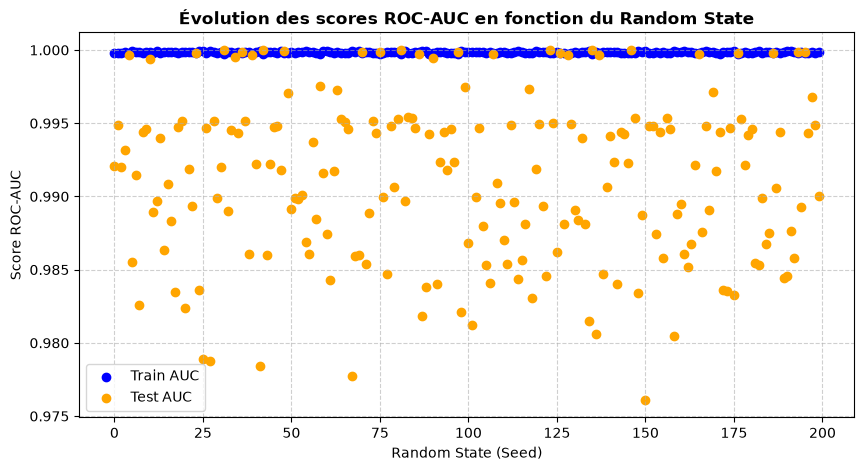

Score Test Moyen : 0.9912
Écart-type Test (Variance) : 0.0056


In [129]:
results = []

# On teste 200 valeurs de random_state différentes (de 0 à 199)
for seed in range(200):
    # Le random_state change à chaque itération pour le découpage
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    
    # Entraînement du KNN avec K=3
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
    model.fit(X_train, y_train)
    
    # Calcul des scores ROC-AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results.append({
        'random_state': seed,
        'train_auc': train_auc,
        'test_auc': test_auc
    })

# Conversion en DataFrame
df_results = pd.DataFrame(results)

# --- Visualisation des variations ---
plt.figure(figsize=(10, 5))
plt.scatter(df_results['random_state'], df_results['train_auc'], marker='o', label='Train AUC', color='blue')
plt.scatter(df_results['random_state'], df_results['test_auc'], marker='o', label='Test AUC', color='orange')
plt.title("Évolution des scores ROC-AUC en fonction du Random State", fontsize=12, fontweight='bold')
plt.xlabel("Random State (Seed)")
plt.ylabel("Score ROC-AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Affichage des statistiques pour juger de la stabilité
print(f"Score Test Moyen : {df_results['test_auc'].mean():.4f}")
print(f"Écart-type Test (Variance) : {df_results['test_auc'].std():.4f}")

Les scores sur train sont bons (très serrés autour de 100%), le modèle apprend de manière régulière quelque soit le mélange dans les données d'entrainement.

Le score sur les tests sont toujours très bons (entre 98% et 100%, moyenne = 99.17%) et peu variés, le modèle est donc robuste aux nouveaux jeux de données.

Néanmoins il est moins performant que la regression logistique

## Test KNN avec moins de variables

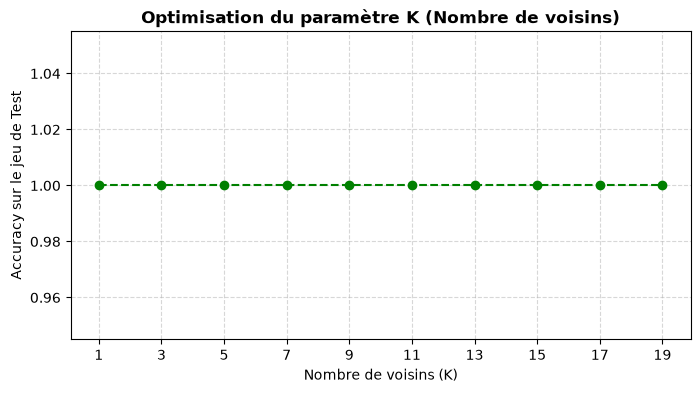

In [130]:
# on relance une instance de train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduit, y, test_size=0.20, random_state=42
)

# On teste les K impairs de 1 à 19 pour éviter les égalités
liste_k = np.arange(1, 20, 2)
scores_test = []

for k in liste_k:
    # On recrée un pipeline avec le k actuel
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train, y_train)
    scores_test.append(model.score(X_test, y_test))

# --- Graphique de l'optimisation de K ---
plt.figure(figsize=(8, 4))
plt.plot(liste_k, scores_test, marker='o', color='green', linestyle='--')
plt.title("Optimisation du paramètre K (Nombre de voisins)", fontsize=12, fontweight='bold')
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Accuracy sur le jeu de Test")
plt.xticks(liste_k)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

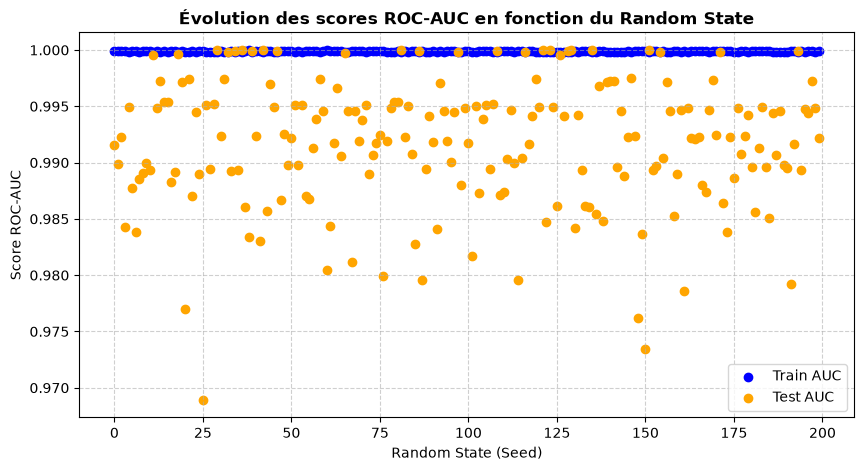

Score Test Moyen : 0.9917
Écart-type Test (Variance) : 0.0057


In [131]:
results = []

# On teste 200 valeurs de random_state différentes (de 0 à 199)
for seed in range(200):
    # Le random_state change à chaque itération pour le découpage
    X_train, X_test, y_train, y_test = train_test_split(X_reduit, y, test_size=0.2, random_state=seed)
    
    # Entraînement de la Régression Logistique
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
    model.fit(X_train, y_train)
    
    # Calcul des scores ROC-AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results.append({
        'random_state': seed,
        'train_auc': train_auc,
        'test_auc': test_auc
    })

# Conversion en DataFrame
df_results = pd.DataFrame(results)

# --- Visualisation des variations ---
plt.figure(figsize=(10, 5))
plt.scatter(df_results['random_state'], df_results['train_auc'], marker='o', label='Train AUC', color='blue')
plt.scatter(df_results['random_state'], df_results['test_auc'], marker='o', label='Test AUC', color='orange')
plt.title("Évolution des scores ROC-AUC en fonction du Random State", fontsize=12, fontweight='bold')
plt.xlabel("Random State (Seed)")
plt.ylabel("Score ROC-AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Affichage des statistiques pour juger de la stabilité
print(f"Score Test Moyen : {df_results['test_auc'].mean():.4f}")
print(f"Écart-type Test (Variance) : {df_results['test_auc'].std():.4f}")

Les résultats sont équivalents à ceux avec toutes les colonnes mais le modèle est plus performant car plus rapide pour la même ROCAUC.

# RandomForest

In [132]:
# on relance une instance de train_test_split mais cette fois-ci sans les données scalées
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [133]:
# 1. On définit la grille des paramètres à tester
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20], # None signifie que l'arbre grandit au maximum
    'min_samples_split': [2, 5, 10]    # Nombre minimum d'individus pour couper un nœud
}

# 2. On instancie le modèle de base (sans lui donner de paramètres spécifiques)
rf = RandomForestClassifier(random_state=8)

# 3. On configure le GridSearchCV
# cv=5 signifie qu'il va faire une validation croisée en 5 blocs pour chaque combinaison
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc',  # ou 'accuracy' selon ce que l'on souhaite
    n_jobs=-1,          # Utilise tous les cœurs de ton processeur pour aller plus vite !
    verbose=1           # Affiche l'avancement des calculs
)

# 4. On lance la recherche sur le jeu d'entraînement
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=8)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_g

In [134]:
# Afficher la meilleure combinaison trouvée
print("Meilleurs hyperparamètres :", grid_search.best_params_)
print(f"Meilleur score de validation croisée : {grid_search.best_score_:.4f}")

# Récupérer automatiquement le meilleur modèle déjà entraîné
best_rf = grid_search.best_estimator_

# Tu n'as plus qu'à évaluer CE modèle sur ton jeu de test
test_score = best_rf.score(X_test, y_test)
print(f"ROC_AUC finale sur le jeu de test : {test_score:.4f}")

Meilleurs hyperparamètres : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Meilleur score de validation croisée : 0.9991
ROC_AUC finale sur le jeu de test : 0.9966


In [135]:
rf_final = grid_search.best_estimator_ # pas besoin de l'entrainer, c'est déjà fait

# On va d'abord générer les prédictions
y_pred = rf_final.predict(X_test)
y_probs = rf_final.predict_proba(X_test)[:, 1]

In [136]:
data = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_final.feature_importances_
})

data = data.sort_values(by='Importance', ascending=False)

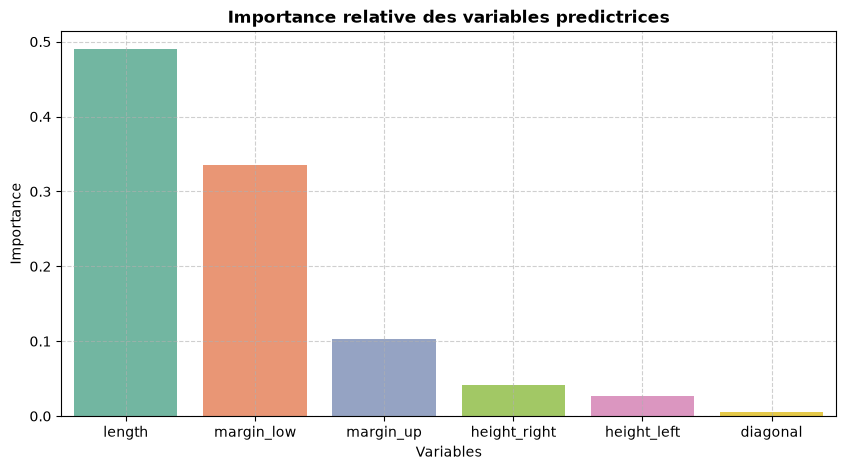

In [137]:
plt.figure(figsize=(10, 5))
sns.barplot(x=data['Feature'], y=data['Importance'], hue=rf_final.feature_importances_, palette='Set2',legend=False)
plt.title("Importance relative des variables predictrices", fontsize=12, fontweight='bold')
plt.xlabel("Variables")
plt.ylabel("Importance")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


       RÉSUMÉ DES PERFORMANCES
Accuracy  (Précision globale) : 0.9966
Precision (Fiabilité du Vrai) : 1.0000
Recall    (Taux de détection) : 0.9949
F1-Score  (Synthèse P/R)      : 0.9975
ROC-AUC   (Pouvoir séparateur): 1.0000


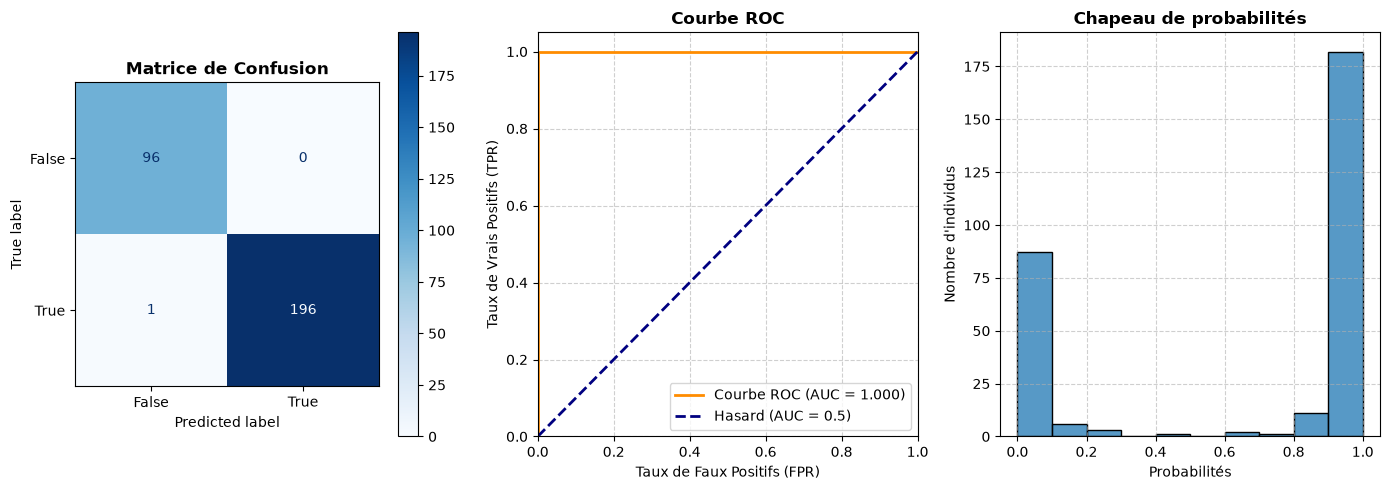

In [138]:
# On Calcule les métriques individuelles
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

# Affichage textuel propre
print("="*40)
print("       RÉSUMÉ DES PERFORMANCES")
print("="*40)
print(f"Accuracy  (Précision globale) : {accuracy:.4f}")
print(f"Precision (Fiabilité du Vrai) : {precision:.4f}")
print(f"Recall    (Taux de détection) : {recall:.4f}")
print(f"F1-Score  (Synthèse P/R)      : {f1:.4f}")
print(f"ROC-AUC   (Pouvoir séparateur): {roc_auc:.4f}")
print("="*40)

# Affichage des graphiques (Matrice de confusion, Courbe ROC et Chapeau de probabilités)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

# --- Graphique 1 : Matrice de Confusion ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_final.classes_)
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title("Matrice de Confusion", fontsize=12, fontweight='bold')

# --- Graphique 2 : Courbe ROC ---
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.5)')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("Taux de Faux Positifs (FPR)")
ax2.set_ylabel("Taux de Vrais Positifs (TPR)")
ax2.set_title("Courbe ROC", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc="lower right")

# --- Graphique 3 : Chapeau de probabilités ---
sns.histplot(y_probs)
ax3.set_xlabel("Probabilités")
ax3.set_ylabel("Nombre d'individus")
ax3.set_title("Chapeau de probabilités", fontsize=12, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Les scores sont bons sur notre seed, le modèle n'a que un faux négatif. Mais testons le sur 200 seeds ici aussi pour voir sa robustesse.

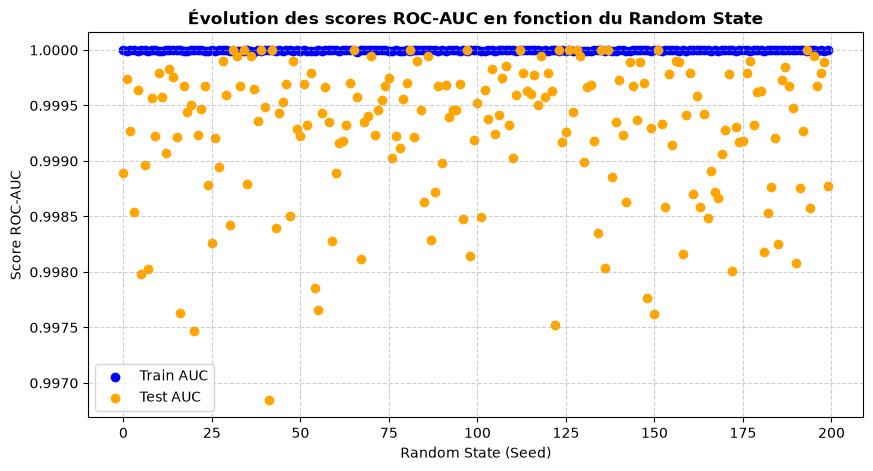

Score Test Moyen : 0.9993
Écart-type Test (Variance) : 0.0006


In [139]:
results = []

# On teste 200 valeurs de random_state différentes (de 0 à 199)
for seed in range(200):
    # Le random_state change à chaque itération pour le découpage
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    
    # Entraînement de la Régression Logistique
    model = RandomForestClassifier(random_state=seed, max_depth=7, min_samples_split=4, n_estimators=100)
    model.fit(X_train, y_train)
    
    # Calcul des scores ROC-AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results.append({
        'random_state': seed,
        'train_auc': train_auc,
        'test_auc': test_auc
    })

# Conversion en DataFrame
df_results = pd.DataFrame(results)

# --- Visualisation des variations ---
plt.figure(figsize=(10, 5))
plt.scatter(df_results['random_state'], df_results['train_auc'], marker='o', label='Train AUC', color='blue')
plt.scatter(df_results['random_state'], df_results['test_auc'], marker='o', label='Test AUC', color='orange')
plt.title("Évolution des scores ROC-AUC en fonction du Random State", fontsize=12, fontweight='bold')
plt.xlabel("Random State (Seed)")
plt.ylabel("Score ROC-AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Affichage des statistiques pour juger de la stabilité
print(f"Score Test Moyen : {df_results['test_auc'].mean():.4f}")
print(f"Écart-type Test (Variance) : {df_results['test_auc'].std():.4f}")

Les scores sont excellents, le modèle est le plus performant parmi ceux testés.

## RandomForest avec X_reduit

In [140]:
# on relance une instance de train_test_split mais cette fois-ci sans les données scalées
X_train, X_test, y_train, y_test = train_test_split(
    X_reduit, y, test_size=0.20, random_state=42
)

In [141]:
# 1. On définit la grille des paramètres à tester
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20], # None signifie que l'arbre grandit au maximum
    'min_samples_split': [2, 5, 10]    # Nombre minimum d'individus pour couper un nœud
}

# 2. On instancie le modèle de base (sans lui donner de paramètres spécifiques)
rf = RandomForestClassifier(random_state=8)

# 3. On configure le GridSearchCV
# cv=5 signifie qu'il va faire une validation croisée en 5 blocs pour chaque combinaison
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc',  # ou 'accuracy' selon ce que l'on souhaite
    n_jobs=-1,          # Utilise tous les cœurs de ton processeur pour aller plus vite !
    verbose=1           # Affiche l'avancement des calculs
)

# 4. On lance la recherche sur le jeu d'entraînement
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=8)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_g

In [142]:
# Afficher la meilleure combinaison trouvée
print("Meilleurs hyperparamètres :", grid_search.best_params_)
print(f"Meilleur score de validation croisée : {grid_search.best_score_:.4f}")

# Récupérer automatiquement le meilleur modèle déjà entraîné
best_rf = grid_search.best_estimator_

# Tu n'as plus qu'à évaluer CE modèle sur ton jeu de test
test_score = best_rf.score(X_test, y_test)
print(f"ROC_AUC finale sur le jeu de test : {test_score:.4f}")

Meilleurs hyperparamètres : {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Meilleur score de validation croisée : 0.9987
ROC_AUC finale sur le jeu de test : 0.9932


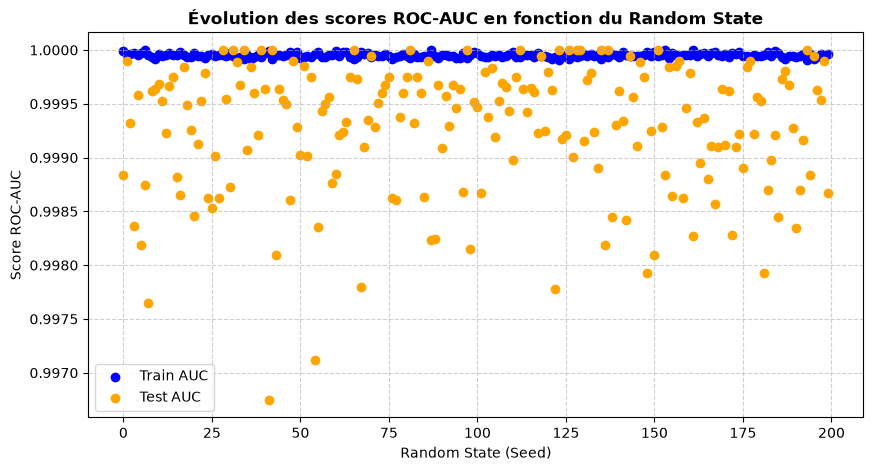

Score Test Moyen : 0.9993
Écart-type Test (Variance) : 0.0006


In [143]:
results = []

# On teste 200 valeurs de random_state différentes (de 0 à 199)
for seed in range(200):
    # Le random_state change à chaque itération pour le découpage
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    
    # Entraînement de la Régression Logistique
    model = RandomForestClassifier(random_state=seed, max_depth=5, min_samples_split=10, n_estimators=200)
    model.fit(X_train, y_train)
    
    # Calcul des scores ROC-AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results.append({
        'random_state': seed,
        'train_auc': train_auc,
        'test_auc': test_auc
    })

# Conversion en DataFrame
df_results = pd.DataFrame(results)

# --- Visualisation des variations ---
plt.figure(figsize=(10, 5))
plt.scatter(df_results['random_state'], df_results['train_auc'], marker='o', label='Train AUC', color='blue')
plt.scatter(df_results['random_state'], df_results['test_auc'], marker='o', label='Test AUC', color='orange')
plt.title("Évolution des scores ROC-AUC en fonction du Random State", fontsize=12, fontweight='bold')
plt.xlabel("Random State (Seed)")
plt.ylabel("Score ROC-AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Affichage des statistiques pour juger de la stabilité
print(f"Score Test Moyen : {df_results['test_auc'].mean():.4f}")
print(f"Écart-type Test (Variance) : {df_results['test_auc'].std():.4f}")

Même remarque que pour les autres modèles. Ces 3 variables suffisent à entrainer le modèle de manière aussi efficace que sur l'ensemble des données.

# Bonus : Le GradientBoostingClassifier

In [144]:
# on relance une instance de train_test_split mais cette fois-ci sans les données scalées
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [145]:
# 1. On définit la grille des paramètres à tester
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 6, 7, 8], # None signifie que l'arbre grandit au maximum
    'min_samples_split': [4, 5, 6],    # Nombre minimum d'individus pour couper un nœud
    'learning_rate': [0.05, 0.1, 0.2, 0.5]
}

# 2. On instancie le modèle de base (sans lui donner de paramètres spécifiques)
rf = GradientBoostingClassifier(random_state=8)

# 3. On configure le GridSearchCV
# cv=5 signifie qu'il va faire une validation croisée en 5 blocs pour chaque combinaison
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc',  # ou 'accuracy' selon ce que l'on souhaite
    n_jobs=-1,          # Utilise tous les cœurs de ton processeur pour aller plus vite !
    verbose=1           # Affiche l'avancement des calculs
)

# 4. On lance la recherche sur le jeu d'entraînement
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...andom_state=8)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [5, 6, ...], 'min_samples_split': [4, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_au

In [146]:
# Afficher la meilleure combinaison trouvée
print("Meilleurs hyperparamètres :", grid_search.best_params_)
print(f"Meilleur score de validation croisée : {grid_search.best_score_:.4f}")

# Récupérer automatiquement le meilleur modèle déjà entraîné
best_rf = grid_search.best_estimator_

# Tu n'as plus qu'à évaluer CE modèle sur ton jeu de test
test_score = best_rf.score(X_test, y_test)
print(f"ROC_AUC finale sur le jeu de test : {test_score:.4f}")

Meilleurs hyperparamètres : {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 150}
Meilleur score de validation croisée : 0.9990
ROC_AUC finale sur le jeu de test : 1.0000


In [147]:
xg_final = grid_search.best_estimator_ # pas besoin de l'entrainer, c'est déjà fait

# On va d'abord générer les prédictions
y_pred = xg_final.predict(X_test)
y_probs = xg_final.predict_proba(X_test)[:, 1]

In [148]:
data = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xg_final.feature_importances_
})

data = data.sort_values(by='Importance', ascending=False)

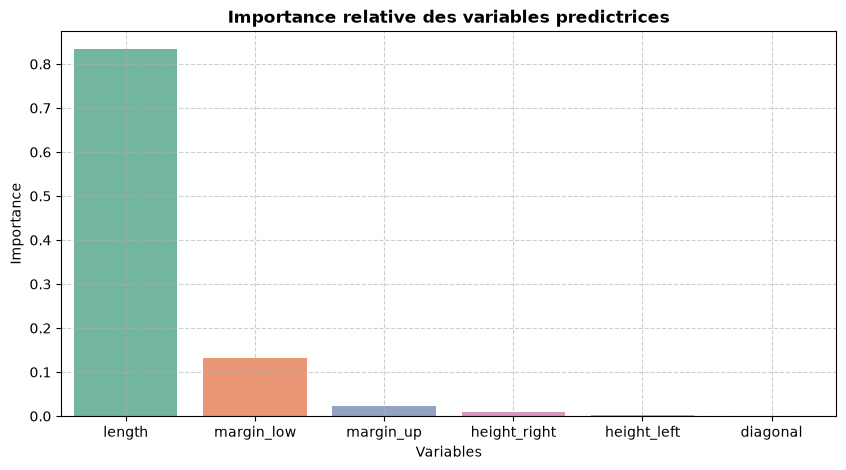

In [149]:
plt.figure(figsize=(10, 5))
sns.barplot(x=data['Feature'], y=data['Importance'], hue=data['Feature'], palette='Set2')
plt.title("Importance relative des variables predictrices", fontsize=12, fontweight='bold')
plt.xlabel("Variables")
plt.ylabel("Importance")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


       RÉSUMÉ DES PERFORMANCES
Accuracy  (Précision globale) : 1.0000
Precision (Fiabilité du Vrai) : 1.0000
Recall    (Taux de détection) : 1.0000
F1-Score  (Synthèse P/R)      : 1.0000
ROC-AUC   (Pouvoir séparateur): 1.0000


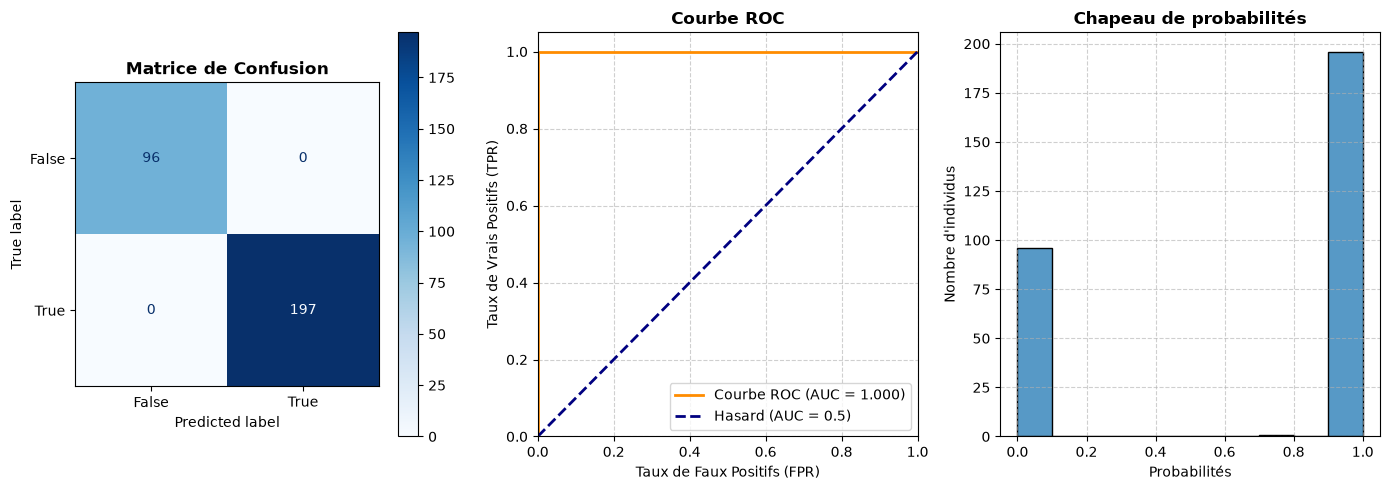

In [150]:
# On Calcule les métriques individuelles
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)

# Affichage textuel propre
print("="*40)
print("       RÉSUMÉ DES PERFORMANCES")
print("="*40)
print(f"Accuracy  (Précision globale) : {accuracy:.4f}")
print(f"Precision (Fiabilité du Vrai) : {precision:.4f}")
print(f"Recall    (Taux de détection) : {recall:.4f}")
print(f"F1-Score  (Synthèse P/R)      : {f1:.4f}")
print(f"ROC-AUC   (Pouvoir séparateur): {roc_auc:.4f}")
print("="*40)

# Affichage des graphiques (Matrice de confusion, Courbe ROC et Chapeau de probabilités)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

# --- Graphique 1 : Matrice de Confusion ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xg_final.classes_)
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title("Matrice de Confusion", fontsize=12, fontweight='bold')

# --- Graphique 2 : Courbe ROC ---
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.5)')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("Taux de Faux Positifs (FPR)")
ax2.set_ylabel("Taux de Vrais Positifs (TPR)")
ax2.set_title("Courbe ROC", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc="lower right")

# --- Graphique 3 : Chapeau de probabilités ---
sns.histplot(y_probs)
ax3.set_xlabel("Probabilités")
ax3.set_ylabel("Nombre d'individus")
ax3.set_title("Chapeau de probabilités", fontsize=12, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

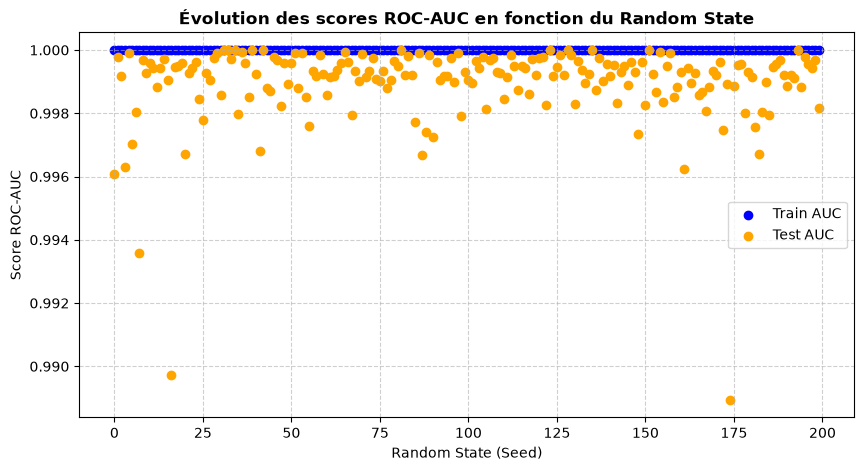

Score Test Moyen : 0.9990
Écart-type Test (Variance) : 0.0013


In [151]:
results = []

# On teste 200 valeurs de random_state différentes (de 0 à 199)
for seed in range(200):
    # Le random_state change à chaque itération pour le découpage
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    
    # Entraînement de la Régression Logistique
    model = GradientBoostingClassifier(learning_rate=0.2, random_state=seed,
                                        max_depth=5, min_samples_split=6, n_estimators=150)
    model.fit(X_train, y_train)
    
    # Calcul des scores ROC-AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    results.append({
        'random_state': seed,
        'train_auc': train_auc,
        'test_auc': test_auc
    })

# Conversion en DataFrame
df_results = pd.DataFrame(results)

# --- Visualisation des variations ---
plt.figure(figsize=(10, 5))
plt.scatter(df_results['random_state'], df_results['train_auc'], marker='o', label='Train AUC', color='blue')
plt.scatter(df_results['random_state'], df_results['test_auc'], marker='o', label='Test AUC', color='orange')
plt.title("Évolution des scores ROC-AUC en fonction du Random State", fontsize=12, fontweight='bold')
plt.xlabel("Random State (Seed)")
plt.ylabel("Score ROC-AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Affichage des statistiques pour juger de la stabilité
print(f"Score Test Moyen : {df_results['test_auc'].mean():.4f}")
print(f"Écart-type Test (Variance) : {df_results['test_auc'].std():.4f}")

Le modèle est excellent mais reste moins performant que RandomForest.

# Comparaison des modèles supervisés :

In [152]:
# définir les modèles à comparer
models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "KNN (k=3)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)),
    "RandomForest": RandomForestClassifier(random_state=42, max_depth=7, min_samples_split=4, n_estimators=100)
    }


In [156]:
# Évaluation moyenne des scores sur 200 seeds
n_seeds = 200
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
summary_results = {name: {metric: [] for metric in metrics} for name in models}

for seed in range(n_seeds):
    # Séparation des données
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=seed, stratify=y
    )

    for name, model in models.items():
        # Entraînement et prédictions
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_probs = model.predict_proba(X_test)[:, 1]

        # Sauvegarde des scores pour cette itération
        summary_results[name]["accuracy"].append(accuracy_score(y_test, y_pred))
        summary_results[name]["precision"].append(precision_score(y_test, y_pred, zero_division=0))
        summary_results[name]["recall"].append(recall_score(y_test, y_pred, zero_division=0))
        summary_results[name]["f1"].append(f1_score(y_test, y_pred, zero_division=0))
        summary_results[name]["roc_auc"].append(roc_auc_score(y_test, y_probs))

# --- CORRECTION ICI ---
# Création propre des lignes pour le DataFrame de résultats
rows = []
for name, model_metrics in summary_results.items():
    row = {"model": name}
    for metric, values in model_metrics.items():
        row[f"mean_{metric}"] = np.mean(values)
        row[f"std_{metric}"] = np.std(values, ddof=1)
    rows.append(row)

# Résumé des moyennes et écarts-types
average_df = pd.DataFrame(rows).set_index("model")

# Affichage des résultats triés par la moyenne du ROC-AUC
pd.options.display.float_format = "{:.4f}".format
print(f"Moyennes et écarts-types des scores sur {n_seeds} seeds :")
display(average_df.sort_values("mean_roc_auc", ascending=False))

Moyennes et écarts-types des scores sur 200 seeds :


,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_roc_auc,std_roc_auc
model,,,,,,,,,,
RandomForest,0.9909,0.0050,0.9898,0.0066,0.9966,0.0041,0.9932,0.0038,0.9993,0.0006
LogisticRegression,0.9913,0.0046,0.9906,0.0060,0.9963,0.0041,0.9934,0.0035,0.9988,0.0016
KNN (k=3),0.9900,0.0050,0.9883,0.0067,0.9968,0.0039,0.9925,0.0038,0.9915,0.0055


# Conclusion

Nous avons 3 modèles performants et robustes (Regression logistique, KNN et RandomForest). Nous devons tester si les modèles font les erreurs sur les mêmes billets ou pas.

Erreurs communes agrégées sur 20 seeds :
   LogisticRegression    KNN  RandomForest  count
0               False  False         False   5782
1               False  False          True     12
2               False   True         False      4
3               False   True          True      4
4                True  False         False      8
5                True  False          True      1
6                True   True         False      6
7                True   True          True     43


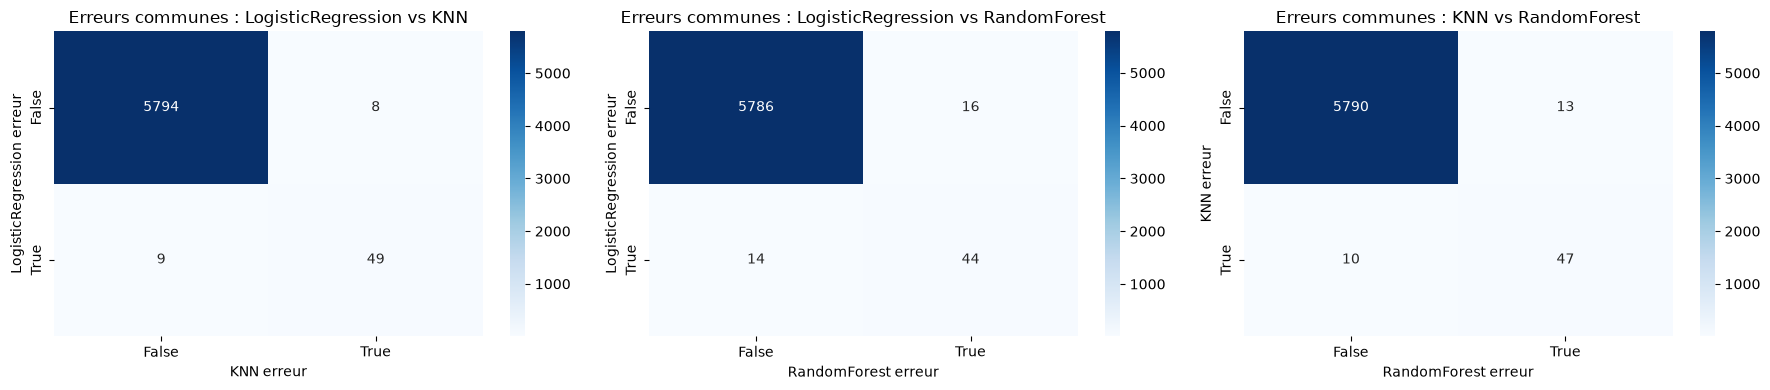

In [ ]:
# Comparaison des erreurs des modèles sur 20 jeux de test différents
error_dfs = []
error_summaries = []

for seed in range(20):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    model_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
    model_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
    model_rf = RandomForestClassifier(random_state=42, max_depth=7, min_samples_split=4, n_estimators=100)

    model_lr.fit(X_train, y_train)
    model_knn.fit(X_train, y_train)
    model_rf.fit(X_train, y_train)

    y_pred_lr = model_lr.predict(X_test)
    y_pred_knn = model_knn.predict(X_test)
    y_pred_rf = model_rf.predict(X_test)

    mask_lr = y_test != y_pred_lr
    mask_knn = y_test != y_pred_knn
    mask_rf = y_test != y_pred_rf

    error_df = pd.DataFrame({
        'seed': seed,
        'LogisticRegression': mask_lr,
        'KNN': mask_knn,
        'RandomForest': mask_rf
    }, index=y_test.index)
    error_dfs.append(error_df)

    error_summary = (
        error_df
        .groupby(['LogisticRegression', 'KNN', 'RandomForest'])
        .size()
        .rename('count')
        .reset_index()
    )
    error_summary['seed'] = seed
    error_summaries.append(error_summary)

combined_errors = pd.concat(error_dfs, ignore_index=True)
combined_summary = pd.concat(error_summaries, ignore_index=True)

agg_summary = (
    combined_summary
    .groupby(['LogisticRegression', 'KNN', 'RandomForest'])
    ['count']
    .sum()
    .reset_index()
)
print("Erreurs communes agrégées sur 20 seeds :")
print(agg_summary)

# Matrices de confusion conjointes agrégées entre paires de modèles
pairs = [
    ('LogisticRegression', 'KNN'),
    ('LogisticRegression', 'RandomForest'),
    ('KNN', 'RandomForest')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (a, b) in zip(axes, pairs):
    cm = pd.crosstab(combined_errors[a], combined_errors[b], rownames=[f'{a} erreur'], colnames=[f'{b} erreur'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"Erreurs communes : {a} vs {b}")

plt.tight_layout()
plt.show()

On voit que nos algorithmes se trompent souvent sur les mêmes billets. Nous allons utiliser le modèle avec le meilleur score : Le RandomForest.

Nous allons créer un script dans lequel ce modèle sera entrainé sur l'ensemble de notre jeu de données pour qu'il teste les futurs billets.